# 🗜️ Stage 2 — CNN Compression of the Anomaly Detector

**Project:** Energy-Aware Visual Anomaly Detection on MCUs — Stage 2 / 4

Takes the FP32 baseline models from Stage 1 and applies three compression families, then characterizes the accuracy/size/compute trade-off.

## What this notebook does

1. Load the Stage 1 baseline checkpoints (`baseline_<cat>.pt`).
2. Re-establish the **scoring protocol** (border crop 4, blur 5, mean pool) — identical to Stage 1.
3. Applies three compression techniques and their combinations:
   - **Post-training quantization** (INT8 dynamic + static)
   - **Structured filter pruning** (L1-norm and Taylor importance, with fine-tuning)
   - **Knowledge distillation** (into a smaller student)
4. Evaluates every variant with the same protocol → AUROC, params, MACs, size.
5. Builds the **Pareto frontier** (AUROC vs. size / MACs).

### Method note on quantization

Since GPUs don't naturally runs INT8 inference the same way as MCUs, so we use PYTorch quantization to estimate the accuracy impact of INT8.
This way we can evaluate weight quantization effects and activation quantization approximation.

- **estimate** the accuracy impact of INT8
- report **theoretical INT8 size** (1 byte/param).

Real memory usage and latency are measured in stage 3 during deployment.

**Stage 2** = math of compression, "model compression effects"

**Stage 3** = physics of deployment, "Hardware execution effects"

---

# Zone 1 — Setup

## 1. Imports & device

In [9]:
!pip install -q ptflops scikit-learn tqdm matplotlib pillow pytorch-msssim torch-pruning

import os, json, copy, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from ptflops import get_model_complexity_info
from pytorch_msssim import ssim
from tqdm.auto import tqdm

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Torch:', torch.__version__, '| Device:', DEVICE)

Torch: 2.11.0+cu128 | Device: cuda


## 2. Data access & Config
- Mount Drive
- pull MVTec dataset into `/content/mvtec/
- define `CFG` -> Configuration Dictionary

Same as Stage 1.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
src = '/content/drive/MyDrive/mvtec'
dst = '/content/mvtec'

# Delete whatever is at dst (/content/mvtec)
if os.path.islink(dst): os.unlink(dst)
elif os.path.isdir(dst): shutil.rmtree(dst)
elif os.path.exists(dst): os.remove(dst)

assert os.path.isdir(src), f'Not found: {src}'
os.symlink(src, dst)

# Pull Stage 1 baselines from Drive backup
# Compressing the exact same trained model - NO retraining
STAGE2_DIR = Path('/content/baseline_out')
STAGE2_DIR.mkdir(exist_ok=True)
drive_baselines = Path('/content/drive/MyDrive/mvtec_stage1')
if drive_baselines.exists():
    for f in drive_baselines.glob('*'):
        shutil.copy(f, STAGE2_DIR / f.name)
    print('Baselines copied:', [f.name for f in STAGE2_DIR.glob('*.pt')])
else:
    print('WARNING: no Drive baseline backup found. Upload baseline_<cat>.pt to', STAGE2_DIR)

CFG = {
    'data_root': '/content/mvtec',
    'image_size': 64,
    'base_channels': 32,
    'latent_channels': 32,
    'n_down': 3,
    'batch_size': 32,
    'out_dir': '/content/stage2_out',
}
Path(CFG['out_dir']).mkdir(exist_ok=True)

# FROZEN scoring protocol — identical to Stage 1
PROTOCOL = {'border': 4, 'blur_kernel': 5, 'pool': 'mean', 'image_size': 64}
print('Protocol:', PROTOCOL)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Baselines copied: ['baseline_bottle.pt', 'baseline_hazelnut.pt']
Protocol: {'border': 4, 'blur_kernel': 5, 'pool': 'mean', 'image_size': 64}


## 3. Datasets
Same as Stage 1

Create/ load different Dataset classes:
- `MVTecTrain` - load "good" training images
- `MVTecTest` - load all test images for evaluation
- `CachedDataset` (RAM-cached for faster epochs -> load image once, store in RAM, reuse in subsequent epochs -> only apply transformations repeatedly)

Image Preprocessing Pipeline:
- Resize -> !! SRAM usage after deployment
- Center crop
- Random horizontal flip - data augmentations: more robust against small changes
- Small random rotation - data augmentations: more robust against small changes
- Convert to a PyTorch tensor

In [11]:
class MVTecTrain(torch.utils.data.Dataset):
    def __init__(self, root, image_size, augment=True):
        self.paths = sorted(Path(root, 'train/good').rglob('*.png'))
        tfs = [transforms.Resize(image_size+16), transforms.CenterCrop(image_size)]
        if augment:
            tfs += [transforms.RandomHorizontalFlip(), transforms.RandomRotation(5)]
        tfs += [transforms.ToTensor()]
        self.tf = transforms.Compose(tfs)
    def __len__(self): return len(self.paths)
    def __getitem__(self, i): return self.tf(Image.open(self.paths[i]).convert('RGB'))

class MVTecTest(torch.utils.data.Dataset):
    def __init__(self, root, image_size):
        self.items = []
        for sub in sorted(Path(root, 'test').iterdir()):
            if not sub.is_dir(): continue
            label = 0 if sub.name == 'good' else 1
            for p in sorted(sub.rglob('*.png')):
                self.items.append((p, label, sub.name))
        self.tf = transforms.Compose([
            transforms.Resize(image_size+16), transforms.CenterCrop(image_size),
            transforms.ToTensor()])
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, label, defect = self.items[i]
        return self.tf(Image.open(p).convert('RGB')), label, defect

class CachedDataset(torch.utils.data.Dataset):
    def __init__(self, base_ds, has_labels=False):
        self.has_labels = has_labels; self.tf = base_ds.tf
        if has_labels:
            self.data = [(Image.open(p).convert('RGB').copy(), l, d) for p, l, d in base_ds.items]
        else:
            self.data = [Image.open(p).convert('RGB').copy() for p in base_ds.paths]
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        if self.has_labels:
            img, l, d = self.data[i]; return self.tf(img), l, d
        return self.tf(self.data[i])

#
def make_loaders(category):
    cat_dir = Path(CFG['data_root']) / category
    tr = CachedDataset(MVTecTrain(cat_dir, CFG['image_size'], augment=True),  has_labels=False)
    te = CachedDataset(MVTecTest(cat_dir,  CFG['image_size']),                has_labels=True)
    # calibration loader: used for Quantization and Pruning
    #   -> NO augmentation, distorts activation statistics (inaccurate quantization and noisy Pruning)
    cal = CachedDataset(MVTecTrain(cat_dir, CFG['image_size'], augment=False), has_labels=False)
    return (DataLoader(tr,  batch_size=CFG['batch_size'], shuffle=True,  num_workers=0, drop_last=True),
            DataLoader(te,  batch_size=CFG['batch_size'], shuffle=False, num_workers=0),
            DataLoader(cal, batch_size=CFG['batch_size'], shuffle=False, num_workers=0))

## 4. Model — CompactAE
Same as Stage 1

adding *load_baseline(category)*
 - Load checkpoint
 - Rebuild architecture
 - Load weights

--> Every compression starts from same function

In [12]:
def conv_block(in_c, out_c, stride=2):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 4, stride, 1, bias=True),
        nn.ReLU(inplace=True),
    )

def upconv_block(in_c, out_c, last=False):
    # Upsample (nearest, CMSIS-friendly) + regular conv, replaces ConvTranspose2d
    layers = [
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(in_c, out_c, 3, 1, 1, bias=True),   # 3x3 conv, stride 1, pad 1 → same spatial size
    ]
    if not last:
        layers.append(nn.ReLU(inplace=True))
    return nn.Sequential(*layers)

class CompactAE(nn.Module):
    def __init__(self, base=32, latent=32, n_down=3):
        super().__init__()
        chans = [3] + [base*(2**i) for i in range(n_down)] + [latent]
        self.enc = nn.Sequential(*[conv_block(chans[i], chans[i+1]) for i in range(len(chans)-1)])
        rev = list(reversed(chans))
        self.dec = nn.Sequential(*[
            upconv_block(rev[i], rev[i+1], last=(i==len(rev)-2))
            for i in range(len(rev)-1)
        ], nn.Sigmoid())
    def forward(self, x):
        return self.dec(self.enc(x))
def build_baseline_model():
    return CompactAE(CFG['base_channels'], CFG['latent_channels'], CFG['n_down'])

# Bridge Stage 1 and Stage 2
def load_baseline(category):
    ckpt = torch.load(STAGE2_DIR / f'baseline_{category}.pt', map_location=DEVICE, weights_only=False)
    m = build_baseline_model().to(DEVICE)
    m.load_state_dict(ckpt['state_dict'])
    return m, ckpt

## 5. Frozen scoring + metrics
`score_images` is byte-identical to Stage 1. -> Create anomaly scores for test images

`measure_model` returns params/MACs/size for the Pareto table -> Size and computation expenses

### Note on metrics

 - **Number of parameters** - flash usage/ model complexity
 - **MACs** - Computations cost per inference (latency/ energy usage)
 - **Size** - Estimated weight storage size
    
    ⚠️ Does not include activations, buffers, runtime overhead -> weight-only estimate (not real RAM usage)

In [13]:
@torch.no_grad()
def score_images(model, loader, protocol=PROTOCOL):
    model.eval()
    border = protocol['border']; k = protocol['blur_kernel']; pool = protocol['pool']
    scores, labels = [], []
    for x, y, d in loader:
        x = x.to(DEVICE)
        x_hat = model(x)
        err = (x - x_hat).pow(2).mean(dim=1)
        if border > 0: err = err[:, border:-border, border:-border]
        err = F.avg_pool2d(err.unsqueeze(1), k, 1, k//2).squeeze(1)
        B, H, W = err.shape; flat = err.view(B, -1)
        if pool == 'max':       s = flat.amax(dim=1)
        elif pool == 'top1pct': s = flat.topk(max(1, H*W//100), dim=1).values.mean(dim=1)
        else:                   s = flat.mean(dim=1)
        scores.append(s.cpu().numpy()); labels.append(y.numpy())
    return np.concatenate(scores), np.concatenate(labels)

# Convert continuous scores and binary labels into AUROC performance number
def auroc_of(model, loader):
    s, l = score_images(model, loader)
    return roc_auc_score(l, s)

def measure_model(model):
    model_cpu = copy.deepcopy(model).cpu().eval()
    n_params = sum(p.numel() for p in model_cpu.parameters())
    macs, _ = get_model_complexity_info(
        model_cpu, (3, CFG['image_size'], CFG['image_size']),
        as_strings=False, print_per_layer_stat=False, verbose=False)
    return {'n_params': n_params, 'macs': int(macs),
            'fp32_kb': n_params*4/1024, 'int8_kb': n_params/1024}

# Sparsity -> How many weights left after Pruning
def count_nonzero_params(model):
    return sum((p != 0).sum().item() for p in model.parameters())

## 6. Fine-tuning helper

Since after
 - Pruning
 - Quantization simulation
 - Distillation

accuracy is lost, short retraining is used to recover performance. -> *finetune(model, train_loader, epochs=30, lr=5e-4)*

Same Loss function as Stage 1 (MSE + SSIM).

In [14]:
def recon_loss(x_hat, x):
    return 0.5*F.mse_loss(x_hat, x) + 0.5*(1 - ssim(x_hat, x, data_range=1.0, size_average=True))

def finetune(model, train_loader, epochs=30, lr=5e-4):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    for ep in range(epochs):
        for x in train_loader:
            x = x.to(DEVICE)
            loss = recon_loss(model(x), x)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    return model

# Zone 2 — Compression techniques
*Each technique is a function: baseline model in → compressed model + metrics out.*

          Stage 1 Baseline (FP32)
                    │
     ┌──────────────┼──────────────┐
     │              │              │
Quantization     Pruning      Distillation
     │              │              │
     └──────────────┼──────────────┘
                    │
       Final INT8 quantization
                    │
           Evaluate (same protocol)
                    │
      AUROC + Params + MACs + Size
                    │
            Build Pareto frontier

## 7. Post-training quantization (INT8 estimate)

 - Simulate INT8 Quantization
 - The model still executes in FP32, but the weights have the precision they would have after quantization.
 - Check how much accuracy is lost by quantization

**Note:**

PyTorch quantizes Linear/LSTM layers well but conv-quantization on CPU is limited
 - --> most reliable estimate is *static* quantization v
    - Simulate INT8 quantization of weights to 8-bit and measure AUROC

In [ ]:
@torch.no_grad()
def fake_quantize_int8(model):
    """Simulate per-tensor symmetric INT8 weight quantization. Backend-independent
    estimate of the accuracy impact. Activations left in FP32 (weight-only sim)."""
    qmodel = copy.deepcopy(model)
    for m in qmodel.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            w = m.weight.data
            scale = w.abs().max() / 127.0
            if scale > 0:
                m.weight.data = torch.round(w / scale).clamp(-127, 127) * scale
    return qmodel

def compress_quantize(baseline, train_loader, test_loader, category):
    q = fake_quantize_int8(baseline).to(DEVICE)
    m = measure_model(baseline)            # param count unchanged
    m['int8_kb'] = m['n_params']/1024      # the whole point: INT8 storage
    m['fp32_kb'] = m['n_params']/1024      # deployed as INT8
    return {'name': 'INT8 (sim)', 'model': q, 'auroc': auroc_of(q, test_loader),
            **m, 'technique': 'quantization'}

## 8. Structured filter pruning (L1 & Taylor)

*"Remove unnecessary parts of the network"*

 - Untructured Filter Pruning
    - remove indiviual weights --> creates many zeros, matrix size remains unchanged
 - Structured Filter Pruning
    - remove entire filters (output channels) --> architecture shrinks

`torch-pruning` for dependency-aware structured pruning

--> removes whole conv filters and the matching input channels downstream, so the model genuinely shrinks.

### Pruning criteria:

 - **L1-norm** (Each filter receives an importance score based on the magnitude of its weights)
 - **Taylor** (first-order, gradient-based --> Prune with taking the gradient of the loss with respect to that weight into accoutn --> approximate loss if filter disappeared)

 Each prune step is followed by short fine-tuning.

### Important note:

Use `calibration loader`because data cannot be augmented, it distorts activation statistics.

 - Since Taylor Pruning is gradient-based, gradients need to reflect true data distribution rather than random transformations

In [ ]:
def manual_structured_prune(baseline, ratio=0.3, method='l1', cal_loader=None):
    model = copy.deepcopy(baseline).to(DEVICE)

    if method == 'taylor':
        if cal_loader is None:
            raise ValueError('Taylor needs cal_loader')
        model.train()
        for p in model.parameters(): p.requires_grad_(True)
        model.zero_grad()
        x = next(iter(cal_loader)).to(DEVICE)
        recon_loss(model(x), x).backward()
        model.eval()

    def importance(weight, grad, dim_reduce):
        if method == 'l1':
            return weight.abs().sum(dim=dim_reduce)
        elif method == 'taylor' and grad is not None:
            return (weight * grad).abs().sum(dim=dim_reduce)
        return weight.abs().sum(dim=dim_reduce)

    with torch.no_grad():
        # ---- Encoder: conv at enc[i][0] (unchanged) ----
        enc = [model.enc[i][0] for i in range(len(model.enc))]
        n_enc = len(enc)
        enc_keep = [None] * n_enc
        for i in range(n_enc - 1):
            imp = importance(enc[i].weight.data, enc[i].weight.grad, (1,2,3))
            n_keep = max(1, int(round(enc[i].out_channels * (1 - ratio))))
            enc_keep[i] = torch.topk(imp, n_keep).indices.sort().values

        # ---- Decoder: conv is now at dec[i][1] (Upsample is at [0]) ----
        # dec blocks: [Upsample, Conv2d, ReLU?]. Last real block before Sigmoid.
        dec = []
        for i in range(len(model.dec) - 1):       # exclude final Sigmoid
            blk = model.dec[i]
            # find the Conv2d inside this block
            conv = None
            for sub in blk:
                if isinstance(sub, nn.Conv2d):
                    conv = sub; break
            if conv is not None:
                dec.append((i, conv))
        n_dec = len(dec)
        dec_keep = [None] * n_dec
        for j in range(n_dec - 1):                # don't prune last conv (3ch output)
            _, conv = dec[j]
            imp = importance(conv.weight.data, conv.weight.grad, (1,2,3))  # Conv2d: [out,in,h,w]
            n_keep = max(1, int(round(conv.out_channels * (1 - ratio))))
            dec_keep[j] = torch.topk(imp, n_keep).indices.sort().values

        # ---- Rebuild encoder ----
        prev = None
        for i in range(n_enc):
            w = enc[i].weight.data.clone()
            b = enc[i].bias.data.clone() if enc[i].bias is not None else None
            if prev is not None: w = w[:, prev, :, :]
            if enc_keep[i] is not None:
                w = w[enc_keep[i]]
                if b is not None: b = b[enc_keep[i]]
                prev = enc_keep[i]
            else:
                prev = None
            new = nn.Conv2d(w.shape[1], w.shape[0], 4, 2, 1, bias=b is not None).to(DEVICE)
            new.weight.data = w
            if b is not None: new.bias.data = b
            model.enc[i][0] = new

        # ---- Rebuild decoder convs (now Conv2d, 3x3, at index [1]) ----
        for j in range(n_dec):
            dec_idx, conv = dec[j]
            w = conv.weight.data.clone()          # [out, in, 3, 3]
            b = conv.bias.data.clone() if conv.bias is not None else None
            if prev is not None: w = w[:, prev, :, :]    # prune input channels
            if dec_keep[j] is not None:                   # prune output channels
                w = w[dec_keep[j]]
                if b is not None: b = b[dec_keep[j]]
                prev = dec_keep[j]
            else:
                prev = None
            new = nn.Conv2d(w.shape[1], w.shape[0], 3, 1, 1, bias=b is not None).to(DEVICE)
            new.weight.data = w
            if b is not None: new.bias.data = b
            # write back to the conv position inside the block
            for k, sub in enumerate(model.dec[dec_idx]):
                if isinstance(sub, nn.Conv2d):
                    model.dec[dec_idx][k] = new
                    break

    for p in model.parameters():
        p.requires_grad_(True); p.grad = None
    return model

In [ ]:
import torch_pruning as tp

def compress_prune(baseline, train_loader, cal_loader, test_loader, category,
                   ratio=0.3, method='l1', finetune_epochs=30):
    n_before = sum(p.numel() for p in baseline.parameters())
    model = manual_structured_prune(baseline, ratio=ratio, method=method, cal_loader=cal_loader)
    n_after = sum(p.numel() for p in model.parameters())
    print(f'    pruned: {n_before:,} -> {n_after:,} params ({100*(1-n_after/n_before):.0f}% removed)')

    if n_after >= n_before:
        raise RuntimeError('Pruning removed nothing.')

    # sanity: forward pass must still work
    with torch.no_grad():
        x = torch.randn(1, 3, CFG['image_size'], CFG['image_size']).to(DEVICE)
        out = model(x)
        assert out.shape == x.shape, f'Output shape broke: {out.shape}'

    model = finetune(model, train_loader, epochs=finetune_epochs)
    m = measure_model(model)
    return {'name': f'Prune {int(ratio*100)}% ({method})', 'model': model,
            'auroc': auroc_of(model, test_loader), **m,
            'technique': f'pruning_{method}'}

In [ ]:
baseline, _ = load_baseline('bottle')
pruned = manual_structured_prune(baseline, ratio=0.5, method='l1')
n0 = sum(p.numel() for p in baseline.parameters())
n1 = sum(p.numel() for p in pruned.parameters())
print(f'{n0:,} -> {n1:,} ({100*(1-n1/n0):.0f}% removed)')

# Verify forward pass + shape
x = torch.randn(2, 3, 64, 64).to(DEVICE)
out = pruned(x)
print('Output shape:', out.shape, '(should be [2, 3, 64, 64])')

361,283 -> 116,659 (68% removed)
Output shape: torch.Size([2, 3, 64, 64]) (should be [2, 3, 64, 64])


## 9. Knowledge distillation

A smaller **student** AE is trained to match the teacher's reconstruction *and* the ground-truth input.

 - **Teacher**: Large model with `base channels = 32` and `latent channels = 32`
 - **Student**: Smaller model with `base channels = 16` and `latent channels = 16`
    - fewer base channels and tighter latent

Loss = α·L(student-vs-input) + (1−α)·L(student-vs-teacher-output)

                |                                 |
        keep student faithful to data       imitate teacher

Student learns from richer model, not only from input pixels alone.

In [ ]:
def compress_distill(teacher, train_loader, test_loader, category,
                     student_base=16, student_latent=16, epochs=80, alpha=0.5):
    student = CompactAE(student_base, student_latent, CFG['n_down']).to(DEVICE)
    teacher = teacher.to(DEVICE).eval()
    opt = torch.optim.Adam(student.parameters(), lr=1e-3, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    for ep in range(epochs):
        student.train()
        for x in train_loader:
            x = x.to(DEVICE)
            with torch.no_grad():
                t_out = teacher(x)
            s_out = student(x)
            loss = alpha*recon_loss(s_out, x) + (1-alpha)*F.mse_loss(s_out, t_out)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    m = measure_model(student)
    return {'name': f'Distill (b{student_base})', 'model': student,
            'auroc': auroc_of(student, test_loader), **m,
            'technique': 'distillation'}

## 10. Combinations
Apply INT8 simulation on top of an already-pruned or distilled model — the realistic deployment path (you always quantize last).

In [ ]:
def add_int8(variant, test_loader):
    q = fake_quantize_int8(variant['model']).to(DEVICE)
    out = dict(variant)
    out['name'] = variant['name'] + ' + INT8'
    out['model'] = q
    out['auroc'] = auroc_of(q, test_loader)
    out['fp32_kb'] = out['n_params']/1024
    out['int8_kb'] = out['n_params']/1024
    out['technique'] = variant['technique'] + '+int8'
    return out

# Zone 3 — Runs
 - Apply all techniques to bottle & hazelnut
 - collect a results table
 - plot Pareto frontier

## 11. Loop over all categories
Run the full sweep on the categories (bottle, hazelnut) and concatenate results.

In [ ]:
import torch, shutil

# Make sure helper columns/structures exist
all_tables = {}
all_variants = {}

for CAT in ['bottle', 'hazelnut']:
    print(f'\n{"#"*60}\n#  {CAT.upper()}\n{"#"*60}')

    # 1. Run the sweep
    table, variants = run_sweep(CAT)

    # 2. Build the table with derived columns
    dfc = pd.DataFrame(table)
    dfc['macs_M'] = (dfc['macs'] / 1e6).round(1)
    dfc['auroc'] = dfc['auroc'].round(4)
    dfc['deployed_kb'] = dfc.apply(
        lambda r: r['n_params'] * (1 if ('int8' in r['technique'] or r['technique'] == 'quantization') else 4) / 1024,
        axis=1).round(1)
    dfc['category'] = CAT
    all_tables[CAT] = dfc
    all_variants[CAT] = variants

    # 3. Save table CSV
    dfc[['name','technique','auroc','n_params','macs_M','deployed_kb']] \
        .sort_values('auroc', ascending=False) \
        .to_csv(Path(CFG['out_dir']) / f'sweep_{CAT}.csv', index=False)

    # 4. Save model checkpoints (with conv_shapes for Stage 3 rebuild)
    for v in variants:
        safe_name = v['name'].replace(' ', '_').replace('%', 'pct').replace('+', 'plus').replace('(', '').replace(')', '')
        shapes = [(m.in_channels, m.out_channels)
                  for m in v['model'].modules()
                  if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d))]
        torch.save({
            'state_dict': v['model'].state_dict(),
            'name': v['name'], 'technique': v['technique'],
            'auroc': v['auroc'], 'n_params': v['n_params'], 'macs': v['macs'],
            'category': CAT, 'conv_shapes': shapes,
        }, Path(CFG['out_dir']) / f'model_{CAT}_{safe_name}.pt')

    # 5. Back up to Drive IMMEDIATELY after each category finishes
    shutil.copytree(CFG['out_dir'], '/content/drive/MyDrive/mvtec_stage2', dirs_exist_ok=True)
    print(f'✓ {CAT}: {len(variants)} checkpoints saved + backed up to Drive')

# 6. Combined CSV
combined = pd.concat(all_tables.values(), ignore_index=True)
combined.to_csv(Path(CFG['out_dir']) / 'sweep_all.csv', index=False)
shutil.copytree(CFG['out_dir'], '/content/drive/MyDrive/mvtec_stage2', dirs_exist_ok=True)

print('\n' + '='*50)
print('DONE. All checkpoints on disk:')
for f in sorted(Path(CFG['out_dir']).glob('model_*.pt')):
    print('  ', f.name)


############################################################
#  BOTTLE
############################################################

  COMPRESSION SWEEP: bottle
Baseline AUROC: 0.9667 | params 361,283
  [1/4] quantization...
  [2/4] pruning l1 30%...
    pruned: 361,283 -> 199,999 params (45% removed)
  [2/4] pruning l1 50%...
    pruned: 361,283 -> 116,659 params (68% removed)
  [2/4] pruning taylor 30%...
    pruned: 361,283 -> 199,999 params (45% removed)
  [2/4] pruning taylor 50%...
    pruned: 361,283 -> 116,659 params (68% removed)
  [3/4] distillation...
  [4/4] done.
✓ bottle: 12 checkpoints saved + backed up to Drive

############################################################
#  HAZELNUT
############################################################

  COMPRESSION SWEEP: hazelnut
Baseline AUROC: 0.8854 | params 361,283
  [1/4] quantization...
  [2/4] pruning l1 30%...
    pruned: 361,283 -> 199,999 params (45% removed)
  [2/4] pruning l1 50%...
    pruned: 361,283 -> 116,659

## Optional: Backup files from Drive.

Create figures without retraining.

In [16]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil

# Pull Stage 2 compressed models from Drive backup
STAGE2_DIR = Path('/content/stage2_out')
STAGE2_DIR.mkdir(exist_ok=True)
drive_stage2 = Path('/content/drive/MyDrive/mvtec_stage2')
if drive_stage2.exists():
    for f in drive_stage2.glob('*'):
        shutil.copy(f, STAGE2_DIR / f.name)
    print('Stage2 copied:', [f.name for f in STAGE2_DIR.glob('*.pt')])
else:
    print('WARNING: no Drive baseline backup found. Upload baseline_<cat>.pt to', STAGE2_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Stage2 copied: ['model_bottle_INT8_sim.pt', 'model_hazelnut_Prune_30pct_taylor.pt', 'model_bottle_Prune_50pct_taylor_plus_INT8.pt', 'model_hazelnut_Prune_30pct_l1_plus_INT8.pt', 'model_bottle_Distill_b16.pt', 'model_bottle_Prune_30pct_l1_plus_INT8.pt', 'model_hazelnut_Distill_b16_plus_INT8.pt', 'model_hazelnut_Distill_b16.pt', 'model_bottle_Distill_b16_plus_INT8.pt', 'model_hazelnut_Prune_50pct_taylor_plus_INT8.pt', 'model_bottle_Prune_30pct_l1.pt', 'model_bottle_Baseline_FP32.pt', 'model_bottle_Prune_30pct_taylor.pt', 'model_bottle_Prune_50pct_taylor.pt', 'model_hazelnut_Prune_50pct_l1_plus_INT8.pt', 'model_bottle_Prune_50pct_l1.pt', 'model_bottle_Prune_50pct_l1_plus_INT8.pt', 'model_bottle_Prune_30pct_taylor_plus_INT8.pt', 'model_hazelnut_Prune_50pct_l1.pt', 'model_hazelnut_INT8_sim.pt', 'model_hazelnut_Prune_30pct_taylor_plus_INT8.pt', 'model_hazelnut_Prun

## 12. Results table

In [17]:
CFG = {'out_dir': '/content/stage2_out'}

all_dfs = {}

for cat in ['bottle', 'hazelnut']:
    df = pd.read_csv(Path(CFG['out_dir']) / f'sweep_{cat}.csv')

    df = df[['name', 'technique', 'auroc', 'n_params', 'macs_M', 'deployed_kb']]
    df = df.sort_values('auroc', ascending=False).reset_index(drop=True)

    all_dfs[cat] = df

    print(f'\n=== {cat.upper()} ===')
    print(df.to_string(index=False))


=== BOTTLE ===
                     name           technique  auroc  n_params  macs_M  deployed_kb
               INT8 (sim)        quantization 0.9738    361283    63.9        352.8
            Baseline FP32                none 0.9667    361283    63.9       1411.3
           Prune 30% (l1)          pruning_l1 0.9659    199999    33.1        781.2
    Prune 30% (l1) + INT8     pruning_l1+int8 0.9595    199999    33.1        195.3
           Prune 50% (l1)          pruning_l1 0.9556    116659    18.3        455.7
    Prune 50% (l1) + INT8     pruning_l1+int8 0.9556    116659    18.3        113.9
       Prune 30% (taylor)      pruning_taylor 0.9532    199999    33.1        781.2
Prune 50% (taylor) + INT8 pruning_taylor+int8 0.9476    116659    18.3        113.9
Prune 30% (taylor) + INT8 pruning_taylor+int8 0.9437    199999    33.1        195.3
       Prune 50% (taylor)      pruning_taylor 0.9333    116659    18.3        455.7
            Distill (b16)        distillation 0.9310     910

## 13. Pareto frontier
AUROC vs. INT8 size, and AUROC vs. MACs.

The Pareto-optimal variants:
 - **no other variant is both smaller/cheaper AND more accurate**

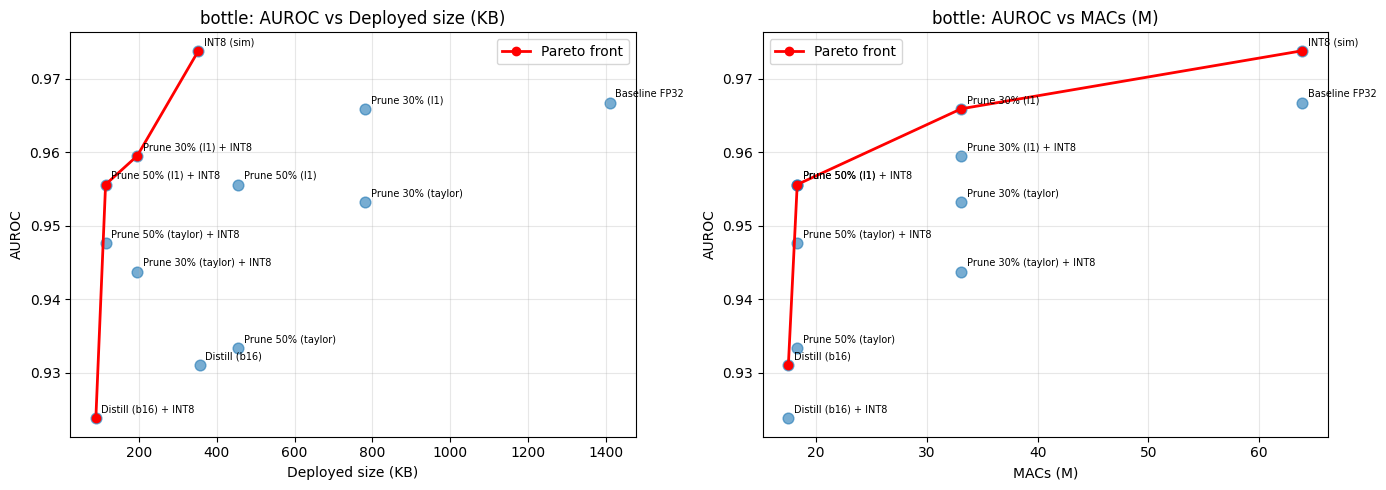

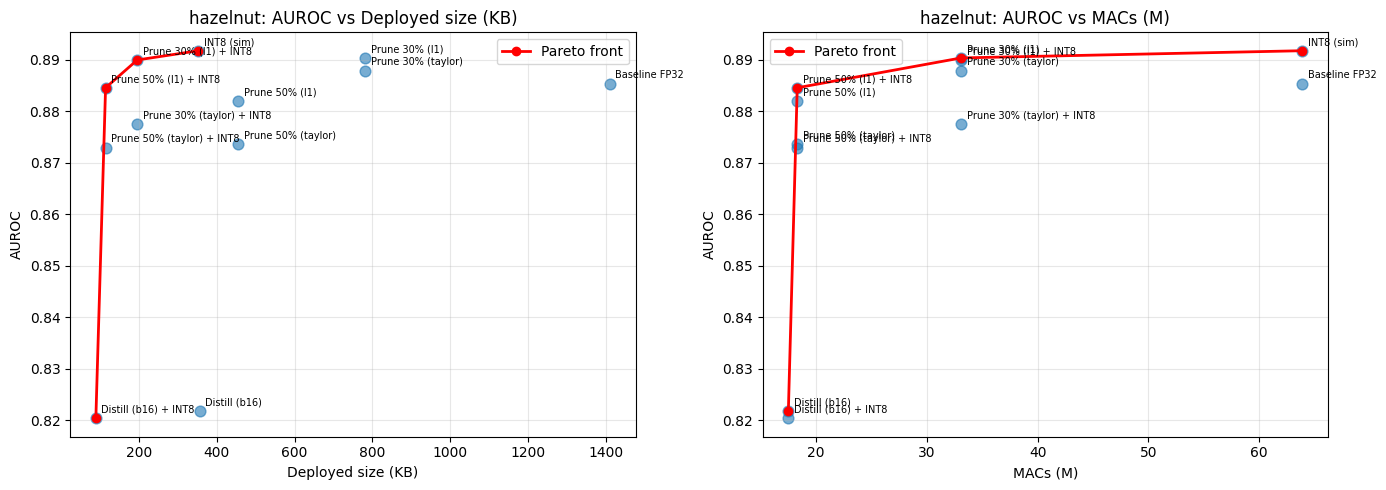

In [19]:
def pareto_front(points):
    pts = sorted(points, key=lambda p: p[0])
    front, best = [], -1
    for x, y, n in pts:
        if y > best:
            front.append((x, y, n))
            best = y
    return front


for CAT in ['bottle', 'hazelnut']:

    dfh = pd.read_csv(Path(CFG['out_dir']) / f'sweep_{CAT}.csv')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, cost_key, label in [
        (axes[0], 'deployed_kb', 'Deployed size (KB)'),
        (axes[1], 'macs_M', 'MACs (M)')
    ]:

        pts = [
            (row[cost_key], row['auroc'], row['name'])
            for _, row in dfh.iterrows()
        ]

        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]

        ax.scatter(xs, ys, s=60, alpha=.6)

        for x, y, n in pts:
            ax.annotate(n, (x, y), fontsize=7,
                        xytext=(4, 4), textcoords='offset points')

        front = pareto_front(pts)
        ax.plot([p[0] for p in front],
                [p[1] for p in front],
                'r-o', lw=2, label='Pareto front')

        ax.set_xlabel(label)
        ax.set_ylabel('AUROC')
        ax.grid(alpha=.3)
        ax.legend()
        ax.set_title(f'{CAT}: AUROC vs {label}')

    plt.tight_layout()
    plt.savefig(Path(CFG['out_dir']) / f'pareto_{CAT}.png',
                dpi=120, bbox_inches='tight')

    plt.show()

# Stage 2 — Report & Stage 3 Handoff

## What Stage 2 produces
For each category: a table of compressed variants with AUROC, parameter count, MACs, and theoretical INT8 size, plus the Pareto frontier (AUROC vs size / MACs). The Pareto-optimal variants are the candidates that move forward to on-device measurement.

- **INT8 here is simulated** (weight-only fake-quantization) for an accuracy estimate. Real INT8 size, latency, and estimated energy are measured in Stage 3 via TFLite Micro on the Arduino.
- **Same frozen protocol** (border 4, blur 5, mean, at 64×64) used for every variant.

## Variants selected for Stage 3
Three rungs per category, chosen to span the Pareto front (accuracy vs MACs / size) while all fitting on-device:
- **Prune 30% L1** — accuracy rung (bottle 0.966, hazelnut 0.890); the most accurate *deployable* point.
- **Prune 50% L1** — near-baseline accuracy, within ~0.01 of prune30 at roughly half the MACs and size (prune30 ≈ 33 MMACs / 195 KB and prune50 ≈ 18 MMACs / 114 KB)
- **Distill b16** — smallest model, lowest-accuracy rung; gives the Stage 4 policy a cheap fallback to degrade to.